<a href="https://colab.research.google.com/github/LSim2002/deep-hedging/blob/main/Part%202%3A%20FFN%20vs%20Signature%20NN%20vs%20LSTM%20(Asian%2C%20Heston).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hedging with Memory: Signatures vs. LSTMs for Path-Dependent Payoffs

This project is inspired from the paper **"Hedging with memory: shallow and deep learning with signatures"** (Abi Jaber & Gerard, arXiv:2508.02759).

The original aim is to show how **signatures combined with a feedforward network** can compensate for — and even outperform — recurrent networks (LSTMs) at capturing path-dependence. This outperformance is observed in the paper under the **geometric Asian option** section: a path-dependent payoff, evaluated even under Markovian dynamics, using **Heston** price paths (a stochastic volatility model).

Following this, we will also work with **geometric Asian options on Heston price movements**. The path-dependence comes from the payoff (a running geometric average of the spot), while the Heston dynamics add stochastic volatility on top.

We compare four hedging strategies:

- **VNN** — a vanilla feedforward network with no signatures, reading the Markovian state $(t, S_t, \Sigma_t)$ pointwise.
- **SNN** — a feedforward network fed the **signature** of the time-augmented path, giving it access to path history in a fixed-dimensional feature vector.
- **LSTM** — a recurrent network that processes the state sequence and builds its own memory representation.
- **Naive vol-blind Black–Scholes baseline** — the closed-form constant-volatility geometric-Asian delta hedge, applied (misspecified) to the stochastic-vol Heston paths. It ignores the volatility state and the leverage/vol-risk-premium, serving as a reference point rather than an optimal hedge.

The central question is whether the **signature + FFN** combination can match or beat the LSTM on a path-dependent hedging problem, while being simpler and more parameter-efficient.

Details, equations, and formulas for each component are introduced as we define the corresponding functions.

#0. Imports

In [ ]:
import math
import re
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.special import ndtr
from scipy.stats import gaussian_kde


# 1. Price path simulation and payoff

## 1.1 Simulate heston price paths

We consider a spot process $S_t$ with dynamics

$$dS_t = S_t \, \Sigma_t \, dB_t$$

under the **Heston (1993)** model — a classical Markovian stochastic volatility model where the volatility $\Sigma_t = \sqrt{V_t}$ is itself driven by a mean-reverting variance process:

$$dV_t = \kappa(\theta - V_t)\, dt + \eta \sqrt{V_t}\, dW_t, \qquad V_0 = \theta.$$

The three variance parameters are:

- $\kappa$ — the **mean-reversion speed**: how fast $V_t$ is pulled back toward its long-run level.
- $\theta$ — the **long-run variance**: the level $V_t$ reverts to on average.
- $\eta$ — the **vol-of-vol**: the volatility of the variance process.




The spot is driven by $B$ and the variance by $W$ — two *different* Brownian motions that we correlate:

$$B = \rho W + \sqrt{1 - \rho^2}\, W^\perp, \qquad W^\perp \perp W \qquad \text{(independent noise)}$$

With $\rho < 0$, a price drop tends to coincide with a rise in volatility — the **leverage effect**.

We work under the risk-neutral measure with $r = 0$, so the spot is driftless.

The model is *Markovian* in the state $(S_t, V_t)$: the volatility is stochastic but carries no path-memory of its own. Any path-dependence in the hedging problem therefore comes entirely from the **payoff**, not the dynamics.

`simulate_heston` — inputs and outputs

**Inputs**

| argument | meaning |
|----------|---------|
| `n_paths` | number of Monte Carlo paths to simulate |
| `n_steps` | number of time steps $J$ (the grid has $J+1$ points $t_0, \dots, t_J$) |
| `T` | maturity (here $T = 0.5$) |
| `s0` | initial spot $S_0$ |
| `v0` | initial variance $V_0$ (set to $\theta$) |
| `kappa`, `theta`, `eta` | Heston variance parameters $\kappa, \theta, \eta$ |
| `rho` | correlation $\rho$ between the spot and variance Brownian motions |
| `seed` | RNG seed for reproducibility |

**Outputs**

| output | shape | meaning |
|--------|-------|---------|
| `S` | `(n_paths, n_steps+1)` | simulated spot on the grid $t_0, \dots, t_J$ |
| `Sigma` | `(n_paths, n_steps+1)` | spot volatility $\sqrt{V_t^+}$ on the same grid |

Both arrays share the same shape: one row per path, one column per grid point. Column $0$ holds the initial values ($S_0$ and $\sqrt{V_0}$, identical across all paths); each subsequent column is one Euler step later.

In [ ]:
def simulate_heston(n_paths, n_steps, T, s0, v0, kappa, theta, eta, rho, seed):
    rng = np.random.default_rng(seed) # rng: modern NumPy Generator, seeded for reproducibility
    dt = T / n_steps # dt: size of one time step (T split into n_steps)
    sqdt = math.sqrt(dt) # sqdt: sqrt(dt), the Brownian increment scale (dW ~ sqrt(dt)*Z)

    S = np.empty((n_paths, n_steps + 1)) # S: init spot paths, n_steps+1 columns to include t=0
    V = np.empty((n_paths, n_steps + 1)) # V: variance paths (V = Sigma^2), same shape as S
    S[:, 0] = s0  # initial spot for every path
    V[:, 0] = v0  # initial variance for every path (v0 = theta here)

    for j in range(n_steps):
        z_w = rng.standard_normal(n_paths) # z_w: standard normal driving W (the variance's BM)
        z_p = rng.standard_normal(n_paths) # z_p: independent normal, the perpendicular noise W^perp
        z_b = rho * z_w + math.sqrt(1.0 - rho * rho) * z_p # z_b: correlated normal driving B (the spot's BM)

        v_plus = np.maximum(V[:, j], 0.0) # v_plus: V^+ = max(V,0), full-truncation so sqrt stays real
        sig = np.sqrt(v_plus) # sig: current volatility Sigma_t = sqrt(V^+)

        S[:, j + 1] = S[:, j] * np.exp(-0.5 * v_plus * dt + sig * sqdt * z_b) # exact GBM step (log-Euler), keeps S > 0 (obtained from applying Ito to log(St))
        V[:, j + 1] = V[:, j] + kappa * (theta - v_plus) * dt + eta * sig * sqdt * z_w # Euler step on the variance SDE

    Sigma = np.sqrt(np.maximum(V, 0.0)) # Sigma: spot volatility on the grid, what the hedger actually sees, assuming the volatility state is perfectly observed. Standard modelling assumption in literature.
    # the point is a relative comparison: VNN vs SNN vs LSTM all get the same idealized state, so the comparison is fair even if the state is unrealistically clean.
    # Also, By handing over Sigma_t, the experiment isolates the payoff's path-dependence (the running geometric average) as the only source of memory the network needs
    return S, Sigma # return spot paths and volatility paths (variance V kept internal)


## 1.2. Geometric asian payoff using running log integral

The geometric Asian payoff depends on the **running integral of log-spot**,

$$A_{t_j} = \int_0^{t_j} \log S_u \, du,$$

because the geometric average is $\exp\!\big(\tfrac{1}{t}\int_0^t \log S_u\,du\big)$. We approximate the integral with the **trapezoidal rule** on the simulation grid, and return the *running* value at every date (not just the final one).

Note the networks never receive $A_{t_j}$ as an input — they only ever see the stream $(t, S_t, \Sigma_t)$. The **VNN** sees just the current point, so it is structurally blind to the average; the **SNN** and **LSTM** see the whole history up to $t_j$ and must reconstruct the average themselves (the signature encodes it, the LSTM builds it in its hidden state). Only the **naive-BS** hedge uses $A_{t_j}$ explicitly, via its closed form.

In [ ]:

def running_log_integral(t_grid, S):
    """A_{t_j} = int_0^{t_j} log S_u du on the grid, trapezoidal rule
    (same quadrature as the payoff, for consistency). Shape (n, J+1)."""
    log_s = np.log(S) # log_s: log-spot, the integrand log S_u
    incr = 0.5 * (log_s[:, 1:] + log_s[:, :-1]) * np.diff(t_grid)[None, :] # incr: trapezoid area on each step, 0.5*(f_j + f_{j+1})*dt
    A = np.zeros_like(S) # A: running integral, starts at 0 since int over [0,0] = 0
    A[:, 1:] = np.cumsum(incr, axis=1) # A_{t_j}: cumulative sum of step areas up to each date
    return A # shape (n, J+1): one running integral value per date, per path





## 1.3. The Geometric Asian Call Payoff

The option pays off on the **geometric average** of the spot over $[0,T]$, not the terminal spot. Its payoff is

$$\xi = \left( \exp\!\Big( \tfrac{1}{T}\int_0^T \log S_t \, dt \Big) - K \right)^{+}.$$

 This is what makes the payoff **path-dependent** — it depends on the whole trajectory, not just $S_T$ — and is the sole source of memory in the hedging problem (recall the Heston dynamics themselves are Markovian).



In [ ]:
def geometric_asian_call_payoff(S, t_grid, strike):

    A = running_log_integral(t_grid, S) # A: running log-integral; we only need its final column
    return np.maximum(np.exp(A[:, -1] / t_grid[-1]) - strike, 0.0) # ( geo-average - K )^+ : exp(A_T / T) is the average, then call payoff



# 2. Markovian states and signatures

## 2.1 Get Markovian states for VNN and LSTM (SignatureNN gets signatures)

In [ ]:
def markovian_features(t_grid, S, Sigma):
    n, j_plus_1 = S.shape                                   # n paths, j_plus_1 = J+1 grid points
    J = j_plus_1 - 1                                        # J hedge dates: we decide a hedge at t_0..t_{J-1}
    tt = np.broadcast_to(t_grid[:J], (n, J))               # tt: the date t_j repeated across every path, shape (n, J)
    feats = np.stack([tt, S[:, :J], Sigma[:, :J]], axis=-1)  # stack (t_j, S_j, Sigma_j) into the last axis -> (n, J, 3)
    return np.ascontiguousarray(feats, dtype=np.float32)   # contiguous float32 for fast/clean handoff to torch

## 2.2 Running path signatures

The **signature** is a *deterministic, predefined* transformation of a path into a fixed-length vector of numbers. It is not learned and has no parameters — the same path always maps to the same features. Its key property is that it is **complete** in the mathematical sense: the signature characterizes the path essentially uniquely (up to negligible reparametrizations), so no path information is lost in principle. That is exactly what we want: fed to a plain feedforward network, the signature is meant to **replace the LSTM's learned memory** with a fixed, structured summary of the history — path-dependence handled by a transformation instead of a recurrent architecture.

The signature is organized into **levels**: level 1 is the path's total increment, level 2 encodes signed areas, and higher levels capture progressively finer detail of the path's shape and ordering. The full signature is infinite, so we **truncate** at a chosen level — the higher the level, the more precise the representation, at the cost of more features. We use level 4 on the $d=3$ path $(t, S_t, \Sigma_t)$, which gives $3 + 9 + 27 + 81 = 120$ features.

We compute the signature exactly for our (piecewise-linear) sampled paths, adding one segment at a time. The algorithmic core is the per-level update

$$L_k^{\text{new}} = \sum_{i=0}^{k} L_i \otimes b_{k-i},$$

which reads simply as: *the new level-$k$ signature is the old level-$k$, plus contributions from combining each lower level $L_i$ already accumulated with the new segment's level-$(k-i)$ term $b_{k-i}$.* The one implementation subtlety is that the higher levels must be updated **before** the lower ones, since each update reads the *old* lower levels. For the full mathematical definition and derivation, refer to the original paper (Section 2).

In [ ]:
def running_signatures(t_grid, S, Sigma):
    n, j_plus_1 = S.shape
    J = j_plus_1 - 1
    d = 3  # path dimension: (t, S, Sigma)

    X = np.empty((n, j_plus_1, d))  # X: the path we take signatures of
    X[:, :, 0] = t_grid[None, :] # channel 0: time (lets the signature see order/direction)
    X[:, :, 1] = S # channel 1: spot
    X[:, :, 2] = Sigma # channel 2: volatility

    out = np.zeros((n, J, d + d**2 + d**3 + d**4), dtype=np.float32)  # 120 features per hedge date; j=0 left zero (single point = no path)

    L1 = np.zeros((n, d))   # L1..L4: running signature levels, start empty
    L2 = np.zeros((n, d**2))
    L3 = np.zeros((n, d**3))
    L4 = np.zeros((n, d**4))

    for j in range(1, J):  # add segment (t_{j-1}, t_j], then store the signature at t_j
        dx = X[:, j, :] - X[:, j - 1, :]  # dx: this segment's increment
        b1 = dx # b_m: the segment's own contribution at level m
        b2 = _outer(dx, dx) / 2.0
        b3 = _outer(b2, dx) / 3.0
        b4 = _outer(b3, dx) / 4.0

        # Chen: (higher levels first, using the not-yet-updated lower levels)
        L4 = L4 + _outer(L3, b1) + _outer(L2, b2) + _outer(L1, b3) + b4 # update higher levels FIRST (they read old lower levels)
        L3 = L3 + _outer(L2, b1) + _outer(L1, b2) + b3
        L2 = L2 + _outer(L1, b1) + b2
        L1 = L1 + b1

        out[:, j, 0:3] = L1  # pack the four levels into the 120-vector at date t_j
        out[:, j, 3:12] = L2
        out[:, j, 12:39] = L3
        out[:, j, 39:120] = L4

    return out # (n, J, 120): running signature per path, per hedge date




`_outer` — the tensor-product step

Each signature level lives in a higher-dimensional space than the last: level 1 has $d=3$ numbers, level 2 has $d^2=9$, level 3 has $27$, level 4 has $81$. Climbing from one level to the next means forming **all pairwise products** of two such blocks of numbers — this is the tensor product, and `_outer` is our batched implementation of it.

Given two blocks of sizes $p$ and $q$ (each a signature level), it produces every product $a_i b_j$, flattened into one vector of size $p \times q$. We run $n$ paths at once, so each block is stored as `(n, p)` — one vector per path — and `_outer` combines them independently within each path, returning `(n, p*q)`. This is the one operation the whole signature computation is built from: every term in the update $L_k = \sum_i L_i \otimes b_{k-i}$

In [ ]:
def _outer(a, b):
    return (a[:, :, None] * b[:, None, :]).reshape(a.shape[0], -1) # batched outer product (n,p)x(n,q)->(n,p*q), flattened
    #None adds a dimension. For ex, if we take a of shape (n, p):
    #a[:, :, None] → shape (n, p, 1) (new axis at the end)
    #b[:, None, :] → shape (n, 1, q) (new axis in the middle))

Later we draw **hedge-ratio surfaces**: $\alpha(t, S)$ across time and spot. Trivial for the VNN (it reads a point), but the SNN and LSTM are path-dependent — they consume a *whole trajectory* leading to $(t, S)$, and infinitely many paths end at the same point. So we fix a **convention**.

**Canonical slice.** For each $(t, S)$, use the **straight-line path** from $(0, S_0)$ to $(t, S)$, with volatility frozen. It's an honest 2-D cross-section of a path-dependent object — not the full hedging rule — answering "what would this method do if the spot had drifted straight to here?" The canonical slice is the simplified stand-in used only for plotting.

**Same convention for the LSTM:** we feed it that same straight-line path as its input sequence and read its final output. All three methods are thus compared on identical slices.

**Why we can shortcut the signature computation here:**  The signature for a straight path has a closed form — no loop needed — because a line has no bends. So for this slice we build the SNN's 120 features directly, in one shot, rather than running the full computation.

**Inputs:** `t_end` (slice time $t$), `s_end` (array of spot values swept), `s0` (path start), `sigma_const` (frozen vol — enters only as a zero increment).
**Output:** `(ns, 120)` — one signature vector per spot value, in the same layout the trained SNN expects.

In [ ]:
def line_signature_features(t_end, s_end, s0):
    ns = len(s_end)
    delta = np.stack([np.full(ns, t_end), s_end - s0, np.zeros(ns)], axis=1) # delta: the line's total increment; vol frozen -> 0
    b1 = delta # the four signature levels of a straight line,
    b2 = _outer(delta, delta) / 2.0 # each just Delta^{ox k} / k! (no Chen loop: a line has no bends)
    b3 = _outer(b2, delta) / 3.0
    b4 = _outer(b3, delta) / 4.0
    return np.concatenate([b1, b2, b3, b4], axis=1).astype(np.float32) # (ns, 120): same feature layout as running_signatures

Note:
* order-0 scalar (== 1) is dropped -> 3 + 9 + 27 + 81 = 120 features, which matches the paper's "120 signature input" / 1442 SNN parameters;
* at j = 0 the path is a single point -> zero feature vector;
* no feature normalization is applied (NONE IS MENTIONED IN THE PAPER).


# 3. Black-Scholes Baseline: Naive (vol&leverage-blind)  geometric-Asian hedge - closed form

## Adapting the European hedging argument to the geometric Asian

**(See `deep hedging project: european call with transaction costs` for the base argument of the European call).**

The setup (GBM, no-arbitrage, replicating portfolio) is unchanged — only the **state** changes. Throughout we use $r = 0$ (risk-neutral, driftless spot), matching the project setup.

The geometric-Asian price depends not just on $(S, t)$ but also on the **running log-integral**

$$A_t = \int_0^t \log S_u\, du, \qquad dA_t = \log S_t\, dt,$$

since the payoff is a function of the average accumulated so far. So we apply Itô's lemma to $V(S, A, t)$ instead of $V(S, t)$. Because $A_t$ has **no diffusion term** ($dA_t$ is pure drift), it contributes only a first-order term:

$$dV = \left(\frac{\partial V}{\partial t} + \tfrac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} + \log S\,\frac{\partial V}{\partial A}\right)dt + \sigma S\frac{\partial V}{\partial S}\, dW_t.$$

Compared to the European case, the only new piece is the transport term $\log S\,\dfrac{\partial V}{\partial A}\,dt$ — everything else is identical.

**Forming the hedge.** The replicating portfolio is the same, $\Pi = V - \Delta S$, so $d\Pi = dV - \Delta\, dS$.


Using the $dV$ and $dS$ formulas :

$$
d\Pi = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2V}{\partial S^2} + \log S\,\frac{\partial V}{\partial A}\right)dt + \sigma S\frac{\partial V}{\partial S}\,dW_t - \Delta \sigma S\, dW_t
$$






Choosing $\Delta = \dfrac{\partial V}{\partial S}$ cancels the $dW_t$ term, leaving $\Pi$ riskless over each instant. No-arbitrage then forces $d\Pi = r\Pi\,dt$, which with $r=0$ means $d\Pi = 0$: the drift bracket must vanish. (This is also where the real-world drift $\mu$ drops out — it never enters the price or hedge, exactly as in the European case.) Setting that bracket to zero gives the **geometric-Asian PDE — the Black–Scholes PDE plus the transport term in $A$:**

$$\frac{\partial V}{\partial t} + \tfrac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} + \log S\,\frac{\partial V}{\partial A} = 0.$$

No new market parameters appear — same $\sigma$, $K$, $T$. The one genuinely new object is the state variable $A_t$, which the hedge must now track.

In principle we'd solve this 2-state PDE with the boundary condition $V(S, A, T) = \big(e^{A/T} - K\big)^+$; in practice we don't need to, because $\log G_T$ is Gaussian and gives the closed form directly.

Writing $\tau = T - t$:

$$C_t = F_G\, N(d_1) - K\, N(d_2), \qquad F_G = e^{m + v/2}, \quad d_1 = \frac{m - \log K + v}{\sqrt{v}}, \quad d_2 = d_1 - \sqrt{v},$$


$$m = \frac{A_t}{T} + \frac{\tau}{T}\log S_t - \frac{\sigma^2\tau^2}{4T}, \quad v = \frac{\sigma^2\tau^3}{3T^2}.$$

which yields:


$$\alpha_t = \frac{\partial C_t}{\partial S_t} = F_G\, N(d_1)\,\frac{\tau}{T\, S_t}.$$

This closed form is what `bs_geo_asian_price_delta` implements, and (with the vol-blind choice $\sigma_{BS} = \sqrt{\theta}$) what the naive baseline hedges with.

**This is NOT the variance-optimal hedge under Heston -- it ignores both the volatility state and the leverage (rho = -0.7); it simply plays the role of a simple, honest benchmark: how well does a trader do if they price and hedge with textbook BS while the world is actually Heston?**

The baseline uses $X_0 = C_0^{BS}$ (its own — biased — price), so its **mean P&L** exposes the Heston-vs-BS pricing gap. Its **mean-squared P&L** combines hedge quality and this pricing bias, since $\text{msq} = \text{Var}(\text{P&L}) + \mathbb{E}[\text{P&L}]^2$; the variance term reflects hedging quality, while the squared-mean term carries the mispricing. (The trained networks learn $X_0$, driving their mean P&L to ≈0, so their msq is almost pure variance)

In [ ]:
def bs_geo_asian_price_delta(tau, S, A, sigma, strike, T):
    # Inputs (all broadcastable together):
    #   tau    : time-to-maturity, shape (1, J) or scalar
    #   S      : spot,             shape (n, J) or scalar
    #   A      : running log-int,  shape (n, J) or scalar
    #   sigma  : scalar (constant vol);  strike, T : scalars


    v = np.maximum(sigma**2 * tau**3 / (3.0 * T**2), 1e-300) # v: floored at zero to avoid /0 when tau->0, shape (1, J)
    m = A / T + (tau / T) * np.log(S) - sigma**2 * tau**2 / (4.0 * T) # shape (n, J)
    sqrt_v = np.sqrt(v) # sqrt_v: shape (1, J)
    d1 = (m - math.log(strike) + v) / sqrt_v  # d1: shape (n, J)
    d2 = d1 - sqrt_v  # d2: shape (n, J)
    f_geo = np.exp(m + 0.5 * v) # shape (n, J)
    price = f_geo * ndtr(d1) - strike * ndtr(d2) # price:  (n, J)
    delta = f_geo * ndtr(d1) * tau / (T * S) # shape (n, J)
    return price, delta # (price, delta) (n, J)


def bs_naive_hedge(t_grid, S, sigma, strike):
    # Inputs:
    #   t_grid : the J+1 grid dates,        shape (J+1,)
    #   S      : Heston spot paths,         shape (n, J+1)
    #   sigma  : constant vol (scalar);  strike : scalar
    T = t_grid[-1]                                          # T: maturity (scalar)
    J = len(t_grid) - 1                                     # J: number of hedge dates (scalar)
    A = running_log_integral(t_grid, S)                     # A: running log-integral along each path; shape (n, J+1)
    tau = (T - t_grid[:J])[None, :]                         # tau: time-to-maturity at each hedge date; shape (1, J)
    _, alpha = bs_geo_asian_price_delta(                    # alpha: BS delta at every (t_j, S_j, A_j); shape (n, J)
        tau, S[:, :J], A[:, :J], sigma, strike, T)          #   -> tau (1,J), S[:, :J] (n,J), A[:, :J] (n,J) broadcast to (n,J)
    x0, _ = bs_geo_asian_price_delta(                       # x0: BS price at t=0 (initial wealth); scalar
        np.array(T), np.array(S[0, 0]),                     #   scalar call: tau=T, S=S0,
        np.array(0.0), sigma, strike, T)                    #   A=0 -> every line in the callee collapses to shape ()
    return alpha.astype(np.float32), float(x0)              # (alpha (n, J) float32, x0 scalar float)

#4. Networks

## The Hedging Networks

All three learned hedgers share the same job: at each date $t_j$, output a hedge ratio $\alpha_j \in (0,1)$, and carry a single trainable scalar $X_0$ (initial wealth). They are trained to minimize the quadratic hedging loss over the terminal P&L (defined in the next section). What differs is **how each sees the path**:

- **VNN (Vanilla NN)** — a feedforward net reading the current state $(t_j, S_j, \Sigma_j)$ *pointwise*. It has no access to history, so it is structurally blind to the running average — our lower bound on what "no memory" achieves.
- **SNN (Signature NN)** — the *same* feedforward architecture, but fed the order-4 **signature** of the path up to $t_j$ (120 features) instead of the raw state. The signature hands it the path history as fixed, precomputed features — memory without recurrence.
- **LSTM (Recurrent NN)** — 3 stacked LSTM layers processing the state *sequence* $(t_j, S_j, \Sigma_j)_j$, building their own memory representation in the hidden state.

Following the paper (Section 3.2), the feedforward hedgers are an *"input layer + 2 hidden layers"* of width 10 with `tanh` activations and a **sigmoid output neuron** (so $\alpha \in (0,1)$); the recurrent hedger is 3 stacked LSTM layers of hidden size 10 with the same sigmoid head. The key comparison the paper draws — and the reason for this project — is **parameter efficiency**:

| Model | Inputs | Trainable params |
|-------|--------|------------------|
| VNN   | $(t, S, \Sigma)$, 3 features | **272** |
| SNN   | order-4 signature, 120 features | **1,442** |
| LSTM  | $(t, S, \Sigma)$ sequence | **~2,372** |

The thesis is that the SNN — a shallow, cheap FFN — can **match or beat the far heavier LSTM** on a path-dependent payoff, because the signature front-loads the path information that the LSTM otherwise has to learn to extract. (On the parameter count: the paper quotes 2,252 for the LSTM; PyTorch reports 2,372 because `nn.LSTM` carries two bias vectors per gate where the paper counts one. The model is identical — see the class docstring.)

In [ ]:
class FFNHedger(nn.Module):
    def __init__(self, in_dim, width=10):   # in_dim: 3 (VNN) or 120 (SNN); width: hidden size (paper: 10)
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, width), nn.Tanh(),   # "input layer"  -> width, tanh
            nn.Linear(width, width), nn.Tanh(),     # hidden layer 1 -> width, tanh
            nn.Linear(width, width), nn.Tanh(),    # hidden layer 2 -> width, tanh
            nn.Linear(width, 1), nn.Sigmoid(),     # output neuron  -> hedge ratio in (0, 1)
        )

        self.X0 = nn.Parameter(torch.zeros(())) # X0: trainable scalar initial wealth; shape () -- init 0 (unspecified in paper)

    def forward(self, feats):          # feats: (..., in_dim) -- any leading batch shape
        return self.net(feats).squeeze(-1)   # -> (...): drops the trailing size-1 axis, giving hedge ratios


class LSTMHedger(nn.Module):
    def __init__(self, in_dim=3, width=10, num_layers=3):  # 3 stacked LSTM layers, hidden size 10, over the (t,S,Sigma) sequence
        super().__init__()
        self.lstm = nn.LSTM(in_dim, width, num_layers=num_layers, batch_first=True)  # batch_first -> expects (B, J, in_dim)
        self.head = nn.Sequential(nn.Linear(width, 1), nn.Sigmoid())  # same sigmoid head -> hedge ratio in (0, 1)
        self.X0 = nn.Parameter(torch.zeros(()))            # X0: trainable scalar initial wealth; shape ()

    def forward(self, feats):                              # feats: (B, J, in_dim) -- the state sequence
        h, _ = self.lstm(feats)                            # h: (B, J, width) hidden state at every date; (h0,c0)=0 by default, as in the paper
        return self.head(h).squeeze(-1)                    # -> (B, J): a hedge ratio at every hedge date, for every path in the batch, in a single call

**What counts as a "sample" differs by architecture.** The FFN sees each $(t, S, \Sigma)$ triple independently — for it, one sample is a *single step*. The LSTM's recurrence needs the whole ordered sequence, so one sample is a *whole path*. We feed both `(B, J, in_dim)` (a batch of paths): the FFN's shape-agnostic `forward` just applies the same net to all $B\times J$ triples at once and reshapes back, while the LSTM scans each sequence internally.


Either way the output is `(B, J)`, and the **loss is per-path** — the $J$ hedge ratios of a path are summed into one P&L (`(alpha * dS).sum(dim=1)`) before averaging over the batch. So we always batch over paths, even though the FFN internally treats steps as samples.

# 5. Training / evaluation


**The hedging P&L.** A hedger is defined by its initial wealth $X_0$ and its hedge ratios $\alpha_j$. Over a path, it holds $\alpha_j$ units of the spot across $(t_j, t_{j+1}]$, so its terminal wealth is $X_0 + \sum_{j=0}^{J-1}\alpha_j\,(S_{j+1}-S_j)$. The **P&L** is that terminal wealth minus the option payoff it must deliver:

$$\text{P&L} = X_0 + \sum_{j=0}^{J-1} \alpha_j\, \Delta S_{j+1} - \xi, \qquad \Delta S_{j+1} = S_{j+1}-S_j.$$

A perfect hedge would give $\text{P&L}=0$ on every path.

**The objective (Section 3.2).** All three networks minimize the **quadratic hedging loss** — the mean squared P&L:

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \big(\text{P&L}_i\big)^2$$




This penalizes hedging error in *both directions* and is what the paper reports (mean-squared P&L).

Note $\mathbb{E}[\text{P&L}^2] = \text{Var}(\text{P&L}) + \mathbb{E}[\text{P&L}]^2$, so the loss captures both hedge *variance* (quality) and any systematic *bias* (mispricing) at once.

**Protocol (paper-faithful - see Algorithm 1).** AdamW (weight decay 0.01), batch 64, 64 epochs. With 10,000 paths that is $\lceil 10000/64\rceil \times 64 = 10{,}048$ steps — the paper's step count, which implies the final partial batch is kept (`drop_last=False`). The learning rate follows a cosine schedule from $10^{-2}$ down to $10^{-3}$ over all steps.

The per-epoch **learning-curve tracking** is *our* diagnostic addition — it is purely observational (evaluates loss on fixed subsets, no early stopping, no model selection), so the training protocol remains exactly the paper's.

UNSURE (not stated in the paper): per-epoch reshuffling (assumed yes); whether weight decay was excluded for X0 / biases (NOT excluded here, i.e. torch's default of decaying every parameter).



In [ ]:
@torch.no_grad()                                           # inference only
def compute_alphas(model, feats, device): # args: feats (n,J,in_dim) tensor or np;  -> returns alpha (n,J) tensor
    model.eval()
    F = torch.as_tensor(feats, device=device)              # F: (n, J, in_dim) (no-op if already a device tensor)
    return model(F)                                         # (n, J) hedge ratios, torch tensor on device


def pnl_from_hedge(alpha, dS, xi, x0): # alpha (n,J) tensor; dS (n,J) tensor; xi (n,) tensor or np; x0 scalar/() tensor or np -> pnl (n,) tensor
    # alpha: (n, J)   dS: (n, J)   xi: (n,)
    return x0 + (alpha * dS).sum(dim=1) - xi               # (n,): X0 + sum_j alpha_j dS_{j+1} - xi, per path


@torch.no_grad()                                           # inference only
def get_model_msqpnl(model, feats, dS, xi, device): # args: model; feats (n,J,in_dim) tensor or np; dS (n,J) tensor or np; xi (n,) tensor or np; device -> returns msq P&L (python float)
    alpha = compute_alphas(model, feats, device)           # (n, J) hedge ratios
    D = torch.as_tensor(dS, device=device)                 # (n, J) increments
    XI = torch.as_tensor(xi, device=device)                # (n,) payoffs
    pnl = pnl_from_hedge(alpha, D, xi=XI, x0=model.X0)      # (n,) per-path P&L (torch)
    return float(pnl.pow(2).mean())                        # scalar msq P&L





def train_hedger(model, train_data, oos_data, n_epochs, batch_size,   #each dataset as a (feats, dS, xi) tuple:
                 lr_start, lr_end, weight_decay, device, label=""):
    model.to(device)

    F, D, XI = (torch.as_tensor(a, device=device) for a in train_data)  # unpack + to device. F: (n, J, in_dim) TRAINING features,   D: (n, J) TRAINING increments, XI: (n,) TRAINING payoffs
    oos_t = tuple(torch.as_tensor(a, device=device) for a in oos_data) # OOS (feats,dS,xi) -> tensors, converted ONCE


    n = F.shape[0]
    steps_per_epoch = math.ceil(n / batch_size)            # ceil(10000/64) = 157 (keeps the final 16-path batch)
    total_steps = steps_per_epoch * n_epochs               # 157 * 64 = 10,048 steps -> matches the paper

    opt = torch.optim.AdamW(model.parameters(), lr=lr_start, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps, eta_min=lr_end)

    print(f"  [{label}] {total_steps} training steps "
          f"({steps_per_epoch} batches x {n_epochs} epochs)")

    # --- learning-curve setup before first epoch (DIAGNOSTIC, observational only) ------------- #
    history = {"epoch": [], "train": [], "oos": [], "time": []}  # time: cumulative wall-clock seconds since training start

    history["epoch"].append(0)                          # epoch-0: UNTRAINED model snapshot
    history["train"].append(get_model_msqpnl(model, F, D, XI, device))
    history["oos"].append(get_model_msqpnl(model, *oos_t, device))
    history["time"].append(0.0)                         # t = 0 at the untrained snapshot

    # --- train loop ------------- #
    model.train()
    t0 = time.time()
    for epoch in range(n_epochs):
        perm = torch.randperm(n, device=device)            # reshuffle path order each epoch
        for b in range(steps_per_epoch):
            idx = perm[b * batch_size:(b + 1) * batch_size]  # this batch's path indices
            alpha = model(F[idx])                           # alpha: (B, J)
            pnl = pnl_from_hedge(alpha, D[idx], XI[idx], model.X0)  # pnl: (B,)
            loss = pnl.pow(2).mean()                        # scalar batch msq P&L
            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()                                    # step LR schedule every optimizer step
        history["epoch"].append(epoch + 1)
        history["train"].append(get_model_msqpnl(model, F, D, XI, device))  # in-sample curve point (full train set)
        history["oos"].append(get_model_msqpnl(model, *oos_t, device))   # OOS curve point (full OOS set)
        history["time"].append(time.time() - t0)          # cumulative wall-clock seconds up to this epoch
        model.train()                                      # get_model_msqpnl left it in eval(); restore
    return model, history





# 6. Hedge surfaces on the canonical slice


This builds the surfaces $\alpha(t, S)$ by applying the **canonical slice** (defined above) to all four methods on a shared $(t, S)$ grid. For each grid point it constructs the straight-line spot path $(0, S_0)\to(t_j, S)$ and feeds each method its appropriate view of it: the naive BS gets the closed form with the line-implied running average, the VNN the endpoint, the SNN the line's signature (closed form), and the LSTM the line as an input sequence. Same slice, four hedgers — directly comparable.

In [ ]:
@torch.no_grad()
def hedge_surfaces_canonical(models, bs_params, t_grid, j_values, s_values,
                             sigma_const, s0, device):
    # models    : {"Vanilla NN": FFNHedger, "Signature NN": FFNHedger, "Recurrent NN": LSTMHedger}
    # bs_params : (sigma_bs, strike) scalars   |   j_values: (nj,) int grid indices   |   s_values: (ns,) spot sweep
    # returns   : {method_name: Z}, each Z of shape (nj, ns) -- hedge ratio on the slice
    sigma_bs, strike = bs_params
    T = t_grid[-1]                                          # T: maturity (scalar)
    ns = len(s_values)                                      # ns: number of spot points swept
    Z = {name: np.empty((len(j_values), ns)) for name in   # Z[name]: (nj, ns) surface, filled row by row
         ["Naive BS (vol-blind)", "Vanilla NN", "Signature NN", "Recurrent NN"]}

    for r, j in enumerate(j_values):                        # r: row index into Z   |   j: grid-date index, t_j = t_grid[j]
        t_j = t_grid[j]                                     # t_j: slice time (scalar)
        # straight-line spot paths (0, s0) -> (t_j, s) on the sim grid up to t_j, for every s in s_values:
        frac = (t_grid[:j + 1] / t_j)[None, :]              # frac: (1, j+1) fraction of the way along the line, in [0,1]
        S_line = s0 + frac * (s_values[:, None] - s0)       # S_line: (ns, j+1) linear spot path per swept s

        # --- naive BS: closed form with the line-implied running average --- #
        A_line = running_log_integral(t_grid[:j + 1], S_line)[:, -1]  # A_line: (ns,) running log-integral at t_j along the line
        _, delta = bs_geo_asian_price_delta(T - t_j, s_values, A_line,
                                            sigma_bs, strike, T)       # delta: (ns,) BS hedge ratio
        Z["Naive BS (vol-blind)"][r] = delta                # fill row r, shape (ns,)

        # --- VNN: pointwise features (t_j, s, sigma_const) ------------------ #
        f = np.stack([np.full(ns, t_j), s_values,
                      np.full(ns, sigma_const)], axis=1).astype(np.float32)  # f: (ns, 3) endpoint states
        Z["Vanilla NN"][r] = models["Vanilla NN"](
            torch.as_tensor(f, device=device)).cpu().numpy()  # model -> (ns,) tensor -> numpy for assignment

        # --- SNN: closed-form line signature (no Chen loop, per above) ------ #
        sig = line_signature_features(t_j, s_values, s0)  # sig: (ns, 120) line signatures
        Z["Signature NN"][r] = models["Signature NN"](
            torch.as_tensor(sig, device=device)).cpu().numpy()  # (ns,) -> numpy

        # --- RNN: feed the whole line as a sequence, read the LAST output --- #
        seq = np.stack([np.broadcast_to(t_grid[:j + 1], (ns, j + 1)),
                        S_line,
                        np.full((ns, j + 1), sigma_const)],
                       axis=-1).astype(np.float32)          # seq: (ns, j+1, 3) the line as an LSTM input sequence
        h = models["Recurrent NN"](torch.as_tensor(seq, device=device))  # h: (ns, j+1) hedge ratio at every step
        Z["Recurrent NN"][r] = h[:, -1].cpu().numpy()       # take the final step (the hedge at t_j) -> (ns,)

    return Z                                                # {name: (nj, ns)} four surfaces on the shared grid

# 7. Plotting functions

## 7.1 Learning curves

**Learning curves (diagnostic).** In-sample and OOS mean-squared P&L per epoch, log scale (solid = OOS, dotted = in-sample), one color per model, with the epoch-0 untrained snapshot as the starting point. Reference lines mark this run's naive-BS msq. It shows convergence speed and any train/OOS gap (overfitting). Purely observational — these evaluations never influence training, so the paper's protocol is unchanged.

In [ ]:
def plot_learning_curves(histories, hlines=None):
    plt.figure(figsize=(7.8, 4.8))
    for name, h in histories.items():
        color, _ = STYLES.get(name, (None, "-"))
        plt.plot(h["epoch"], h["oos"], "-", color=color, lw=1.6,
                 label=f"{name} (OOS)")
        plt.plot(h["epoch"], h["train"], ":", color=color, lw=1.2,
                 alpha=0.55, label=f"{name} (in-sample)")
    for label, (y, color) in (hlines or {}).items():
        plt.axhline(y, color=color, lw=1.0, ls="--", alpha=0.8)
        plt.annotate(label, (0.99, y), xycoords=("axes fraction", "data"),
                     ha="right", va="bottom", fontsize=8, color=color)
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("mean squared P&L")
    plt.title("Learning curves (quadratic hedging loss)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

def plot_learning_curves_time(histories, hlines=None):
    """Same as plot_learning_curves but x-axis = wall-clock seconds, so the
    curves show how much faster (in real time) each method learns."""
    plt.figure(figsize=(7.8, 4.8))
    for name, h in histories.items():
        color, _ = STYLES.get(name, (None, "-"))
        plt.plot(h["time"], h["oos"], "-", color=color, lw=1.6,
                 label=f"{name} (OOS)")
        plt.plot(h["time"], h["train"], ":", color=color, lw=1.2,
                 alpha=0.55, label=f"{name} (in-sample)")
    for label, (y, color) in (hlines or {}).items():
        plt.axhline(y, color=color, lw=1.0, ls="--", alpha=0.8)
        plt.annotate(label, (0.99, y), xycoords=("axes fraction", "data"),
                     ha="right", va="bottom", fontsize=8, color=color)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("wall-clock time (s)")
    plt.ylabel("mean squared P&L")
    plt.title("Learning curves vs. wall-clock time")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 7.2 Plot sample paths

**Sample paths and hedges (paper Fig. 5).** Two OOS trajectories (one OTM-trending, one ITM-trending) with their running geometric average and strike on top, and the four methods' hedge-ratio paths below. This traces the hedges *along real paths* over time, showing how each method reacts to the spot moving — and where the vol-blind BS lags the vol-aware networks.

In [ ]:
def plot_sample_paths(t_grid, S_sel, gbar_sel, strike, alphas_sel):
    """Two OOS spot trajectories (top: spot, running geometric average,
    strike) and the corresponding hedge-ratio paths of every method
    (bottom) -- paper Figure 5 style."""
    J = len(t_grid) - 1
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4), sharex="col",
                             gridspec_kw={"height_ratios": [1.0, 1.35]})
    for c in range(2):
        ax = axes[0, c]
        ax.plot(t_grid, S_sel[c], color="black", lw=1.0, label="Spot")
        ax.plot(t_grid, gbar_sel[c], color="black", lw=1.0, ls=":",
                label="Geometric average")
        ax.axhline(strike, color="0.8", lw=0.9, label="Strike")
        ax.set_ylabel("Spot" if c == 0 else None)
        if c == 0:
            ax.legend(fontsize=8, loc="best")

        ax = axes[1, c]
        for name, al in alphas_sel.items():
            color, ls = STYLES.get(name, (None, "-"))
            ax.plot(t_grid[:J], al[c], ls, color=color, lw=1.2, label=name)
        ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel("t")
        ax.set_ylabel("Hedging ratio" if c == 0 else None)
        if c == 0:
            ax.legend(fontsize=8, loc="best")
    fig.suptitle("Two OOS trajectories and the hedges of each method",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

## 7.3 Plot P&L Density

**P&L density (paper Fig. 4a).** Gaussian-KDE estimates of the OOS terminal-P&L distribution for all four methods on one axis. A better hedge gives a *taller, narrower* density concentrated at 0.

In [ ]:
def plot_pnl_densities(pnls,  xlim=(-0.03, 0.03)):
    """Gaussian-KDE (Scott's rule, as in the paper) OOS P&L densities.
    Colors / line styles follow the paper's figures; x-range as in Fig 4(a)."""
    grid = np.linspace(xlim[0], xlim[1], 601)
    plt.figure(figsize=(7.0, 4.5))
    for name, pnl in pnls.items():
        color, ls = STYLES.get(name, (None, "-"))
        kde = gaussian_kde(pnl)                      # default bw = Scott (1992)
        plt.plot(grid, kde(grid), ls, color=color, label=name)
    plt.axvline(0.0, color="0.75", lw=0.8)
    plt.xlim(*xlim)
    plt.xlabel("P&L")
    plt.ylabel("Density")
    plt.title("Geometric Asian call (ATM, K=1) under Heston: OOS P&L density")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7.4 Plot hedge surfaces

**Hedge-ratio surfaces.** The 2×2 grid of $\alpha(t, S)$ surfaces on the **canonical slice**, one per method. It shows *what each method actually does* as a function of time and spot: how the hedge ratio rises toward 1 as the option goes in-the-money, how it varies with time-to-maturity, and how closely the learned hedgers track (or depart from) the naive BS shape. A qualitative sanity check that the networks learned a sensible, delta-like rule.

In [ ]:
def plot_hedge_surfaces(Z, t_values, s_values):
    """2x2 3-D surfaces of the hedge ratio on the canonical slice."""
    TT, SS = np.meshgrid(t_values, s_values, indexing="ij")
    fig = plt.figure(figsize=(12.5, 9.5))
    for k, (name, zz) in enumerate(Z.items(), start=1):
        ax = fig.add_subplot(2, 2, k, projection="3d")
        ax.plot_surface(TT, SS, zz, cmap="viridis", vmin=0.0, vmax=1.0,
                        linewidth=0, antialiased=True)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("t")
        ax.set_ylabel("S")
        ax.set_zlabel(r"hedge ratio $\alpha$")
        ax.set_zlim(0.0, 1.0)
        ax.view_init(elev=24, azim=-58)
    fig.suptitle("Hedge ratio on the canonical slice "
                 r"(linear spot paths, $\Sigma$ frozen at $\sqrt{\theta}$; "
                 "zero-area slice for the SNN)", fontsize=12)
    sm = plt.cm.ScalarMappable(norm=Normalize(0.0, 1.0), cmap="viridis")
    fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.06,
                 label=r"$\alpha$")
    plt.show()


## 7.5 Plot surface difference

**SNN − BS deviation heatmap.** The difference $\alpha_{\text{SNN}} - \alpha_{\text{BS}}$ on the same slice, with the zero contour marked. This isolates *where* the signature hedger departs from the vol-blind closed form — regions where accounting for the path and stochastic vol changes the prescribed hedge. Blue/red show over/under-hedging relative to BS; the pattern is the learned correction to the misspecified baseline.

In [ ]:
def plot_surface_difference(Z, t_values, s_values,
                            a="Signature NN", b="Naive BS (vol-blind)"):
    """Heatmap of Z[a] - Z[b] on the canonical slice: where the learned
    hedge deviates from the vol-blind closed form."""
    diff = Z[a] - Z[b]
    lim = float(np.abs(diff).max())
    plt.figure(figsize=(7.2, 4.6))
    pcm = plt.pcolormesh(t_values, s_values, diff.T, cmap="RdBu_r",
                         vmin=-lim, vmax=lim, shading="auto")
    cs = plt.contour(t_values, s_values, diff.T, levels=[0.0],
                     colors="k", linewidths=0.8)
    plt.clabel(cs, fmt={0.0: "0"}, fontsize=8)
    plt.colorbar(pcm, label=rf"$\alpha_{{SNN}} - \alpha_{{BS}}$")
    plt.xlabel("t")
    plt.ylabel("S")
    plt.title(f"{a} minus {b} on the canonical slice")
    plt.tight_layout()
    plt.show()


# 8. Run experiment

In [ ]:
#the plot functions look STYLES up as a global
STYLES = {
    "Naive BS (vol-blind)": ("tab:blue", "-"),
    "Vanilla NN":           ("tab:orange", ":"),
    "Signature NN":         ("tab:green", "--"),
    "Recurrent NN":         ("tab:red", "-."),
}

In [ ]:
    # ------------------- experiment parameters (all from the paper) -------- #
    # Heston (Model 1, Section 4):
    S0 = 1.0
    V0 = 0.0625                       # V0 = theta
    KAPPA, THETA, ETA = 4.0, 0.0625, 0.7
    RHO = -0.7
    # Payoff (4.4): ATM fixed-strike geometric Asian call; Heston maturity 6M:
    STRIKE = 1.0
    T = 0.5
    # Grid / data (Section 3.2):
    J = 126                           # hedge dates t_0..t_125; 127 grid points
    N_TRAIN = 10_000
    N_OOS = 20_000
    # Networks:
    WIDTH = 10
    SIG_ORDER_DIM = 3 + 9 + 27 + 81   # order 4 (user choice #1), plain
    #                                   signature (user choice #2), d = 3
    # Training (Section 3.2):
    BATCH_SIZE = 64
    N_EPOCHS = 64                     # -> 10,048 steps, as in the paper
    LR_START, LR_END = 1e-2, 1e-3
    WEIGHT_DECAY = 0.01
    # Naive BS baseline (OUR ADDITION -- the paper has no BS baseline for
    # the Asian/Heston case). CHOICE: the vol-blind hedger uses the constant
    # sigma_BS = sqrt(theta) = sqrt(V0) = 0.25, the natural constant-vol
    # proxy of this Heston parameterization:
    SIGMA_BS = math.sqrt(THETA)
    # Canonical-slice hedge surfaces:
    SURF_S = np.linspace(0.80, 1.20, 41)
    SURF_J = np.unique(np.linspace(2, J - 1, 40).astype(int))
    # Sample-path figure: OOS paths at these quantiles of the terminal
    # geometric average (one OTM-trending, one ITM-trending):
    PATH_QUANTILES = (0.12, 0.88)
    # Learning-curve diagnostics (OUR ADDITION -- observational only, no
    # early stopping / model selection; training protocol unchanged).
    # train_hedger evaluates in-sample (full train) and OOS (full oos_data)
    # loss every epoch; this is the main wall-time overhead, esp. for the LSTM.
    # Reproducibility -- SEEDS ARE NOT GIVEN IN THE PAPER:
    SEED_DATA = 0
    SEEDS_NET = {"Vanilla NN": 1, "Signature NN": 2, "Recurrent NN": 3}
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device: {DEVICE}")

device: cuda


In [ ]:
    # ------------------------------- data ---------------------------------- #
    t_grid = np.linspace(0.0, T, J + 1)

    print("simulating Heston paths...")
    S_tr, Sig_tr = simulate_heston(N_TRAIN, J, T, S0, V0, KAPPA, THETA, ETA, RHO, SEED_DATA)
    S_te, Sig_te = simulate_heston(N_OOS, J, T, S0, V0, KAPPA, THETA, ETA, RHO, SEED_DATA + 1)

    xi_tr = geometric_asian_call_payoff(S_tr, t_grid, STRIKE).astype(np.float32)
    xi_te = geometric_asian_call_payoff(S_te, t_grid, STRIKE).astype(np.float32)
    dS_tr = np.diff(S_tr, axis=1).astype(np.float32)     # (n, J)
    dS_te = np.diff(S_te, axis=1).astype(np.float32)
    print(f"MC price E[xi]: train {xi_tr.mean():.5f} | OOS {xi_te.mean():.5f}")

    # OOS increments / payoffs as device tensors (pnl_from_hedge needs tensors)
    dS_te_t = torch.as_tensor(dS_te, device=DEVICE)
    xi_te_t = torch.as_tensor(xi_te, device=DEVICE)

    mk_tr = markovian_features(t_grid, S_tr, Sig_tr)     # (n, J, 3) VNN + RNN
    mk_te = markovian_features(t_grid, S_te, Sig_te)

    print("computing running order-4 signatures of (t, S, Sigma)...")
    t0 = time.time()
    sig_tr = running_signatures(t_grid, S_tr, Sig_tr)    # (n, J, 120) SNN
    sig_te = running_signatures(t_grid, S_te, Sig_te)
    print(f"  done in {time.time() - t0:.1f}s "
          f"(train {sig_tr.nbytes / 1e9:.2f} GB, OOS {sig_te.nbytes / 1e9:.2f} GB)")

simulating Heston paths...
MC price E[xi]: train 0.03753 | OOS 0.03819
computing running order-4 signatures of (t, S, Sigma)...
  done in 11.0s (train 0.60 GB, OOS 1.21 GB)


In [ ]:
    # ------------------- naive (vol-blind) Black-Scholes ------------------- #
    results = {}     # name -> {"alpha": (n,J) np, "pnl": (n,) np, "x0": float}
    alpha_bs, x0_bs = bs_naive_hedge(t_grid, S_te, SIGMA_BS, STRIKE)
    pnl_bs = pnl_from_hedge(torch.as_tensor(alpha_bs, device=DEVICE),
                            dS_te_t, xi_te_t, x0_bs)
    results["Naive BS (vol-blind)"] = {
        "alpha": alpha_bs,                       # numpy (n, J) for plotting
        "pnl": pnl_bs.cpu().numpy(),             # numpy (n,)
        "x0": x0_bs,
    }
    print(f"\n=== Naive BS (vol-blind) | closed form, sigma_BS = {SIGMA_BS} ===")
    print(f"  BS price X0 = {x0_bs:.5f}  (Heston MC price {xi_te.mean():.5f} "
          f"-> pricing bias {x0_bs - xi_te.mean():+.2e})")


=== Naive BS (vol-blind) | closed form, sigma_BS = 0.25 ===
  BS price X0 = 0.03936  (Heston MC price 0.03819 -> pricing bias +1.17e-03)


**Pricing sanity check (naive BS baseline).**

- `X0 = 0.03936` — closed-form BS price of the geometric Asian call at $t=0$, using constant $\sigma_{BS}=\sqrt{\theta}=0.25$. This is the vol-blind hedger's initial wealth.
- `0.03819` — Monte Carlo price $\mathbb{E}[\xi]$ over the 20k OOS Heston paths (the "true" price under the simulated dynamics).
- `+1.17e-03` — the gap $X_0 - \mathbb{E}[\xi]$: BS slightly **overprices** vs Heston.

The gap is expected: BS assumes flat vol, while Heston has stochastic vol with $\rho=-0.7$ (left skew) that the constant-vol formula can't see. It's small (~3% of price) — the baseline is sane, just not exact. Note $\mathbb{E}[\xi]$ is itself an MC estimate, so part of the gap is sampling noise.

In [ ]:
    # ------------------------- train the three networks -------------------- #
    features = {
        "Vanilla NN":   (mk_tr, mk_te),
        "Signature NN": (sig_tr, sig_te),
        "Recurrent NN": (mk_tr, mk_te),
    }
    models = {}
    histories = {}
    for name in ["Vanilla NN", "Signature NN", "Recurrent NN"]:
        torch.manual_seed(SEEDS_NET[name])   # seeds init + batch shuffling
        if name == "Vanilla NN":
            model = FFNHedger(in_dim=3, width=WIDTH)
        elif name == "Signature NN":
            model = FFNHedger(in_dim=SIG_ORDER_DIM, width=WIDTH)
        else:
            model = LSTMHedger(in_dim=3, width=WIDTH, num_layers=3)

        n_params = sum(p.numel() for p in model.parameters())
        print(f"\n=== {name} | trainable parameters: {n_params} ===")

        f_tr, f_te = features[name]
        model, hist = train_hedger(
            model,
            train_data=(f_tr, dS_tr, xi_tr),
            oos_data=(f_te, dS_te, xi_te),
            n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
            lr_start=LR_START, lr_end=LR_END,
            weight_decay=WEIGHT_DECAY, device=DEVICE, label=name)
        histories[name] = hist

        alpha_t = compute_alphas(model, f_te, device=DEVICE)   # (n, J) tensor
        x0_val = model.X0.detach()                             # no grad, stays a tensor
        pnl_t = pnl_from_hedge(alpha_t, dS_te_t, xi_te_t, x0_val)
        results[name] = {
            "alpha": alpha_t.cpu().numpy(),
            "pnl": pnl_t.detach().cpu().numpy(),
            "x0": float(model.X0),          # fine here — just for printing/storing
        }
        models[name] = model
        print(f"  learned X0 = {float(model.X0):.5f}  (MC price {xi_te.mean():.5f})")


=== Vanilla NN | trainable parameters: 272 ===
  [Vanilla NN] 10048 training steps (157 batches x 64 epochs)
  learned X0 = 0.03862  (MC price 0.03819)

=== Signature NN | trainable parameters: 1442 ===
  [Signature NN] 10048 training steps (157 batches x 64 epochs)
  learned X0 = 0.03861  (MC price 0.03819)

=== Recurrent NN | trainable parameters: 2372 ===
  [Recurrent NN] 10048 training steps (157 batches x 64 epochs)
  learned X0 = 0.03900  (MC price 0.03819)


In [ ]:
    # ------------------------------ report --------------------------------- #
    print("\n================ OOS results (20,000 paths) ================")
    print(f"{'model':<22}{'mean sq P&L':>14}{'mean P&L':>14}{'X0':>10}")
    for name, res in results.items():
        pnl = res["pnl"]
        msq, mp = float(np.mean(pnl**2)), float(np.mean(pnl))
        print(f"{name:<22}{msq:>14.3e}{mp:>14.3e}{res['x0']:>10.4f}")

    pnls = {name: res["pnl"] for name, res in results.items()}


================ OOS results (20,000 paths) ================
model                    mean sq P&L      mean P&L        X0
Naive BS (vol-blind)       8.292e-05     1.441e-03    0.0394
Vanilla NN                 1.176e-04     6.749e-04    0.0386
Signature NN               7.186e-05     6.869e-04    0.0386
Recurrent NN               7.308e-05     1.042e-03    0.0390


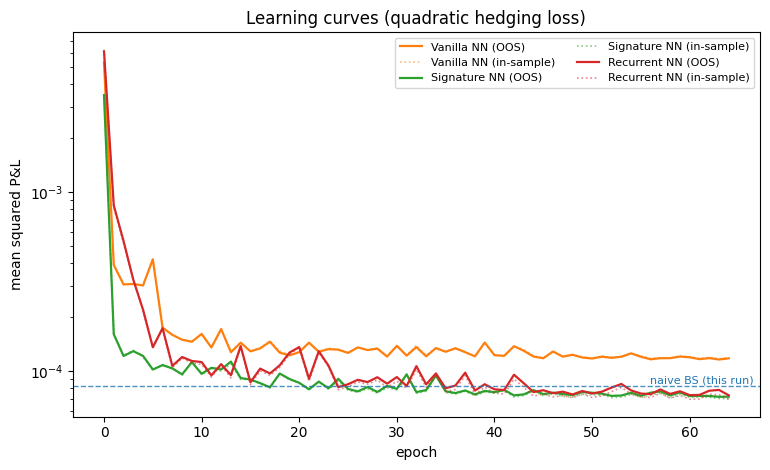

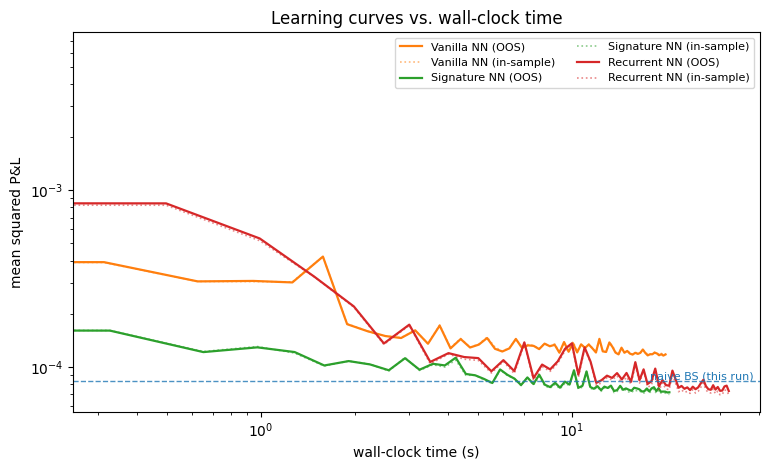

In [ ]:
    # 1. learning curves (diagnostic; solid = OOS, dotted = in-sample)
    msq_bs = float(np.mean(results["Naive BS (vol-blind)"]["pnl"] ** 2))
    plot_learning_curves(
        histories,
        hlines={"naive BS (this run)": (msq_bs, "tab:blue")})
    plot_learning_curves_time(
        histories,
        hlines={"naive BS (this run)": (msq_bs, "tab:blue")})

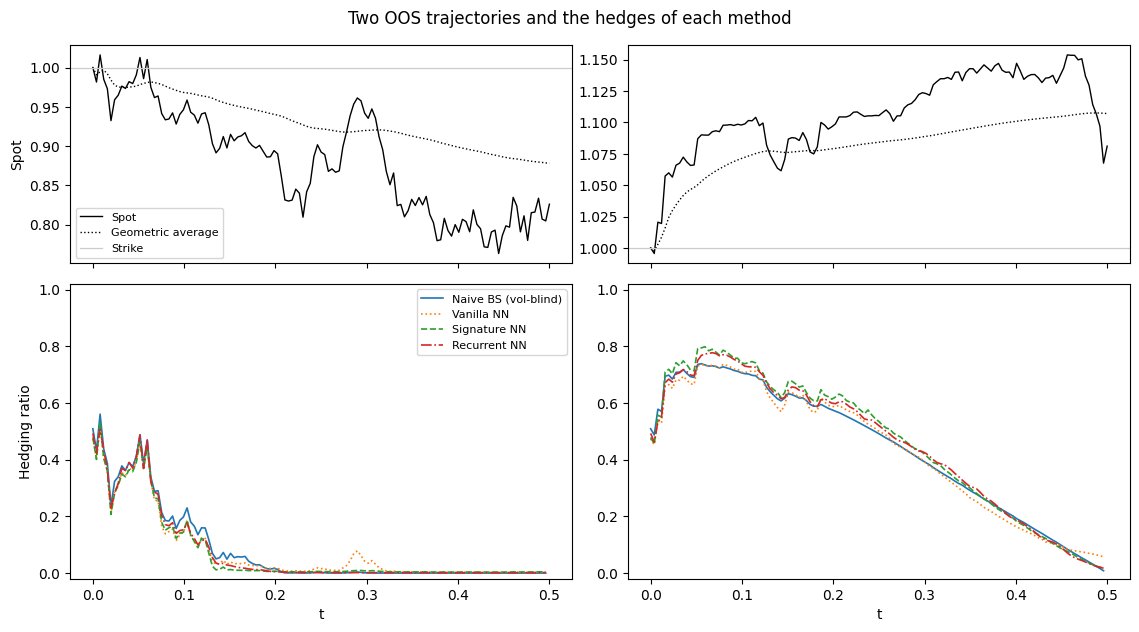

In [ ]:
    # 2. sample paths + hedges
    gbar = np.empty_like(S_te)
    gbar[:, 0] = S_te[:, 0]
    A_te = running_log_integral(t_grid, S_te)
    gbar[:, 1:] = np.exp(A_te[:, 1:] / t_grid[None, 1:])
    order = np.argsort(gbar[:, -1])
    sel = [order[int(q * (N_OOS - 1))] for q in PATH_QUANTILES]
    plot_sample_paths(t_grid, S_te[sel], gbar[sel], STRIKE,
                      {name: res["alpha"][sel] for name, res in results.items()})


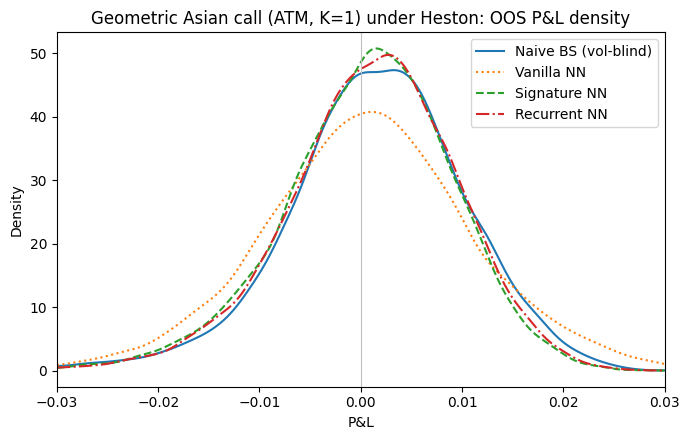

In [ ]:
    # ------------------------------ figures -------------------------------- #
    # 3. P&L densities
    plot_pnl_densities(pnls)


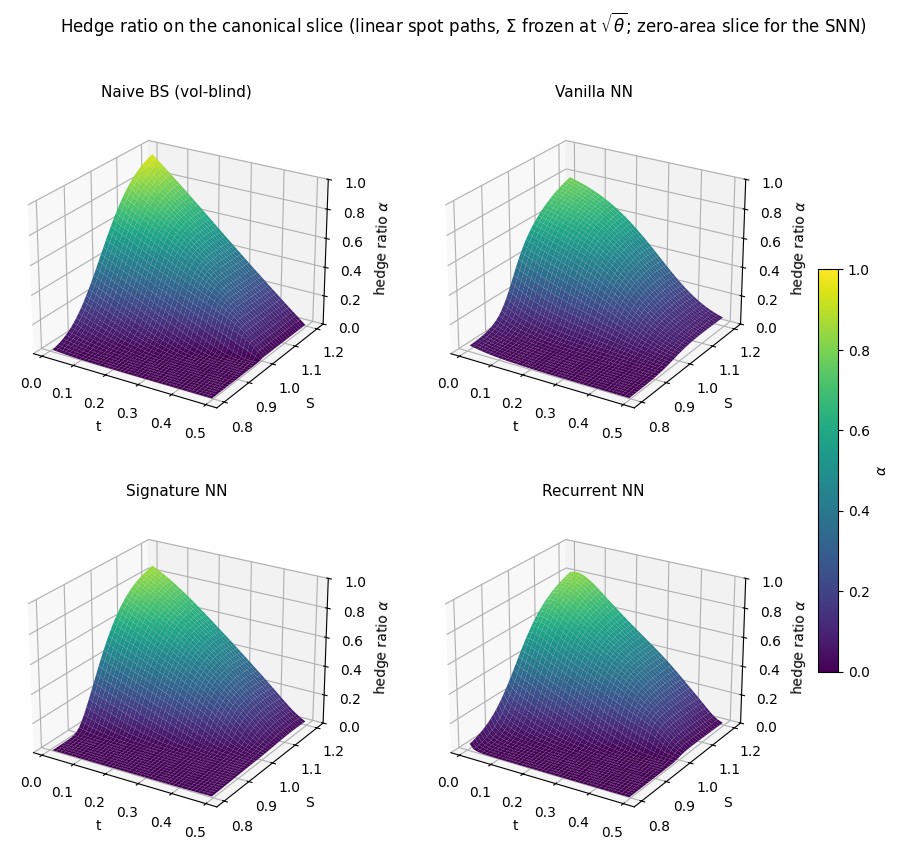

In [ ]:
    # 4-5. hedge surfaces on the canonical slice + SNN-minus-BS deviation
    Z = hedge_surfaces_canonical(models, (SIGMA_BS, STRIKE), t_grid,
                                 SURF_J, SURF_S, SIGMA_BS, S0, DEVICE)
    plot_hedge_surfaces(Z, t_grid[SURF_J], SURF_S)


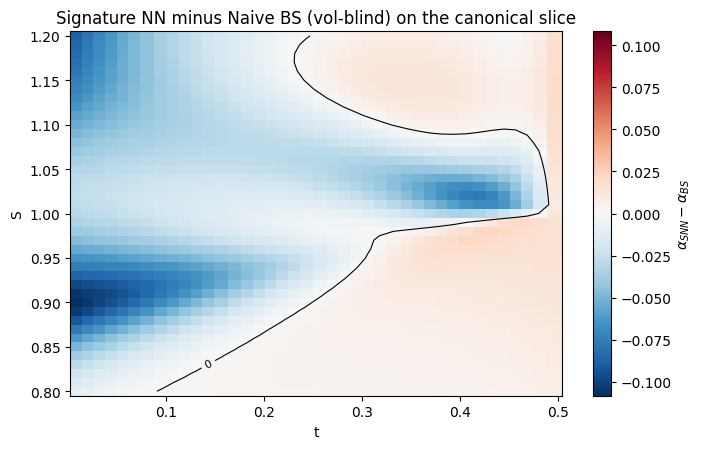

In [ ]:
    plot_surface_difference(Z, t_grid[SURF_J], SURF_S)

# 9. Conclusion

We reproduced the paper's tier structure but not its headline gap. Everything carrying the path-dependent state — SNN (7.19e-5), RNN (7.31e-5), even the vol-blind closed-form BS (8.29e-5) — clusters together, while the Markovian VNN plateaus ~40% higher (1.18e-4).

The takeaway is state beats architecture: what matters is feeding the network the payoff's path-dependence (via signatures, or an explicit running average), not the choice of recurrent vs. feedforward. A plain FFN fed order-4 signatures matches the LSTM's hedge quality (near-identical P&L densities) with far fewer parameters and a shorter training run.


Why the paper's SNN > RNN gap didn't replicate. The paper conjectured the RNN's handicap was overfitting, but our learning curves show train ≈ OOS for the RNN throughout (image 1) — no overfitting at this scale. So the RNN's real disadvantage is optimization speed, not generalization. That convergence-speed edge is the part of the paper's efficiency claim that survives — though on the A100 the wall-clock gap is modest; on CPU it would be much larger.


On the figures, two are worth a sentence:

**P&L density**: SNN and RNN nearly coincide as the tightest distributions; VNN is visibly fatter-tailed. Naive BS tracks them but is shifted right by its small pricing bias.

**SNN − BS heatmap**: the learned hedge sits systematically below the vol-blind delta, most strongly below the money early on. Under ρ = −0.7 that's the minimum-variance correction — the network recovered it without ever being shown it.

